Created on 30/06/26

This file contains tests on possible clustering procedures.

## K-Means (KMeans) from Scikit learn
Main reference (theory and package explanation):\
https://scikit-learn.org/stable/modules/clustering.html#k-means

K-Means is a general purpose clustering algorithm.\
Its complexity is $O(NKT)$, with $N$ number of samples, $C$ number of clusters, and $T$ number of iterations.\
By default, the algorithm minimizes the "inertia", that is the within-cluster sum-of-squares:
\begin{equation*}
\sum_{i=0}^{N} \min_{u_j \in C} (\|x_i - u_j\|^2)
\end{equation*}
where $u_j$ is the $j$-th centroid and $x_i$ is the $i$-th data point.\
K-Means returns centroids, which are the data points that minimize the inertia. In general, centroids do not coincide with any of the original data points. They are "averaged" data points. For this reason, K-Means tends to smooth out peaks in the dataset, which may or may not hinder the quality of the results when reducing time series using a typical day reformulation.

In [3]:
import numpy as np
from sklearn.cluster import KMeans


X = np.array([[1, 2], [1, 4], [1, 0],
              [10, 2], [10, 4], [10, 0]])
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(X)    # basic clastering call

print(kmeans.cluster_centers_)      # coordinates of cluster centers
print(kmeans.labels_)               # labels of each point (i.e., to which cluster center each point belongs)
print(kmeans.inertia_)              # sum of squared distances of samples to their closest cluster center (or centroid)

predict = kmeans.predict([[0, 0], [12, 3]])    # function to predict the cluster centers to which the elements in the argument belong
print(predict)

# fit_predict() can be used to return directly the labels of each point, instead of fitting (.fit()) and then extracting the labels (.labels_))
print(KMeans(n_clusters=2, random_state=0, n_init="auto").fit_predict(X))
print('----------------------------------------------')


X2 = np.array([[0, 1, 1, 2, 1, 0, 3, 5, 7, 2, 0],
               np.array([0, 1, 1, 2, 1, 0, 3, 5, 7, 2, 0]) * 1.1,
               np.array([0, 1, 1, 2, 1, 0, 3, 5, 7, 2, 0]) * 1.05,
               np.array([0, 1, 1, 2, 1, 0, 3, 5, 7, 2, 0]) * 0.9,
               np.array([0, 1, 1, 2, 1, 0, 3, 5, 7, 2, 0]) * 2])
kmeans2 = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(X2)

print(kmeans2.cluster_centers_)
print(kmeans2.labels_)
print(f'Inertia = {kmeans2.inertia_}')

[[10.  2.]
 [ 1.  2.]]
[1 1 1 0 0 0]
16.0
[1 0]
[1 1 1 0 0 0]
----------------------------------------------
[[ 0.      1.0125  1.0125  2.025   1.0125  0.      3.0375  5.0625  7.0875
   2.025   0.    ]
 [ 0.      2.      2.      4.      2.      0.      6.     10.     14.
   4.      0.    ]]
[0 0 0 0 1]
Inertia = 2.056250000000002


The following jupyter cell contains an example from "https://www.w3schools.com/python/python_ml_k-means.asp".

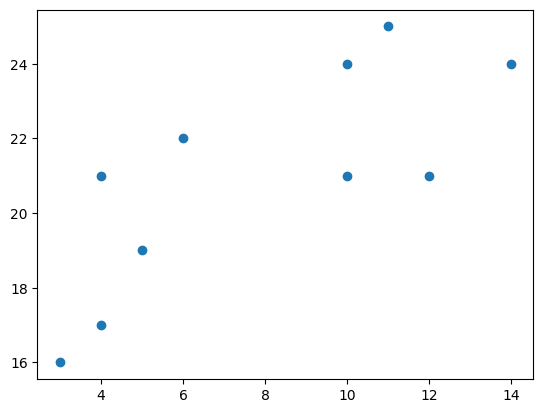

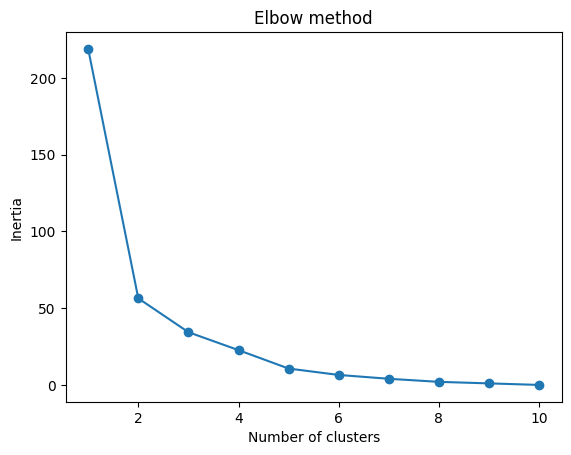

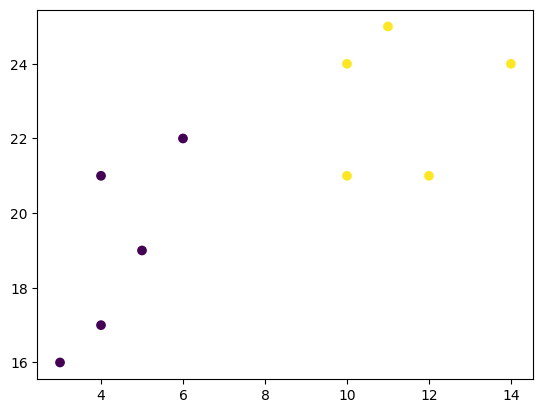

In [4]:
import matplotlib.pyplot as plt

x = [4, 5, 10, 4, 3, 11, 14 , 6, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]

plt.scatter(x, y)
plt.show()

from sklearn.cluster import KMeans

# The function zip() aggregates iterables into tuples; then list() turns the zip object into a list of tuples
# To clarify, in this case, x and y are features of the data points, and each of their elements are associated with different data points.
# The tuples created by zip() are the data points. 
data = list(zip(x, y))

# -----------------------------------------------------------------------------------------------
# "Elbow method" to find the optimal number of clusters (less relevant)
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()
# -----------------------------------------------------------------------------------------------

kmeans = KMeans(n_clusters=2)
kmeans.fit(data)

plt.scatter(x, y, c=kmeans.labels_)
plt.show()

## K-Medoids (KMedoids) from Scikit learn extra
Main references (theory and package explanation):\
https://scikit-learn-extra.readthedocs.io/en/stable/modules/cluster.html \
https://scikit-learn-extra.readthedocs.io/en/stable/generated/sklearn_extra.cluster.KMedoids.html

K-Medoids is similar to K-Means, and it also a general purpose clustering algorithm.\
Its complexity is $O(N^2KT)$, with $N$ number of samples, $C$ number of clusters, and $T$ number of iterations.\
K-Medoids is also based around the concept of inertia, but it tries to minimize the sum of distances between each point and the medoid of its cluster, where medoids, differently from centroids, aree data points belonging to the original dataset.
This means that K-Medoids does not suffer from the same "peak-smoothing" effects of K-Means. However, it is slower, especially when dealing with large sample sizes.

If necessary for computational reasons, the "CLARA" clustering method could be considered. It's also included in the scikit-learn-extra library, and should yield the same results as K-Medoids, but with a more scalable algorithm. 

In [8]:
from sklearn_extra.cluster import KMedoids
import numpy as np


X = np.asarray([[1, 2], [1, 4], [1, 0],
                [4, 2], [4, 4], [4, 0]])
# The method parameter allows one to choose between a faster 'alternate' option (which is the default), and a maore accurate 'pam'
# (Partitioning Around Medoids) option 
kmedoids = KMedoids(n_clusters=2, metric='euclidean', method='alternate', random_state=0).fit(X)

print(kmedoids.cluster_centers_)
print(kmedoids.labels_)
print(kmedoids.inertia_)

predict = kmedoids.predict([[0,0], [4,4]])
print(predict)
print('----------------------------------------------')


X2 = np.array([[0, 1, 1, 2, 1, 0, 3, 5, 7, 2, 0],
               np.array([0, 1, 1, 2, 1, 0, 3, 5, 7, 2, 0]) * 1.1,
               np.array([0, 1, 1, 2, 1, 0, 3, 5, 7, 2, 0]) * 1.05,
               np.array([0, 1, 1, 2, 1, 0, 3, 5, 7, 2, 0]) * 0.9,
               np.array([0, 1, 1, 2, 1, 0, 3, 5, 7, 2, 0]) * 2])
kmedoids2 = KMedoids(n_clusters=2, method='pam', random_state=0).fit(X2)

print(kmedoids2.cluster_centers_)
print(kmedoids2.labels_)
print(f'Inertia = {kmedoids2.inertia_}')

[[1. 2.]
 [4. 2.]]
[0 0 0 1 1 1]
8.0
[0 1]
----------------------------------------------
[[ 0.    1.05  1.05  2.1   1.05  0.    3.15  5.25  7.35  2.1   0.  ]
 [ 0.    2.    2.    4.    2.    0.    6.   10.   14.    4.    0.  ]]
[0 0 0 0 1]
Inertia = 2.4238399287081567
